# 04 Outreach plan: Who should the college help first?
Research question 5: Turn risk scores into a ranked outreach list, match each student to a type of help, and weigh the cost of mistakes.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

df = pd.read_csv('../data/data.csv', sep=';')
df.columns = df.columns.str.strip()
df['dropout'] = (df['Target'] == 'Dropout').astype(int)

CATEGORICAL = ['Marital status', 'Application mode', 'Course', 'Previous qualification',
               'Nacionality', "Mother's qualification", "Father's qualification",
               "Mother's occupation", "Father's occupation"]
SEM1 = [c for c in df.columns if c.startswith('Curricular units 1st sem')]
SEM2 = [c for c in df.columns if c.startswith('Curricular units 2nd sem')]
enroll_features = [c for c in df.columns if c not in ['Target', 'dropout'] + SEM1 + SEM2]
sem1_features = enroll_features + SEM1
CUTOFF = 0.35

X_train, X_test, y_train, y_test = train_test_split(
    df[sem1_features], df['dropout'], test_size=0.2, stratify=df['dropout'], random_state=42)

cats = [c for c in sem1_features if c in CATEGORICAL]
nums = [c for c in sem1_features if c not in CATEGORICAL]
model = Pipeline([
    ('prep', ColumnTransformer([
        ('cat', OneHotEncoder(handle_unknown='ignore'), cats),
        ('num', StandardScaler(), nums)])),
    ('model', LogisticRegression(max_iter=2000, class_weight='balanced')),
])
model.fit(X_train, y_train)
test_prob = model.predict_proba(X_test)[:, 1]
print('Flagged at cutoff:', (test_prob >= CUTOFF).sum())

Flagged at cutoff: 382


**Notes:** Same final model as notebooks 02 and 03: logistic regression after semester 1. The 885 test students stand in for "this semester's students." Each gets a risk score from 0 to 1.

In [2]:
results = X_test.copy()
results['risk'] = test_prob
results['dropped_out'] = y_test
results = results.sort_values('risk', ascending=False)

BUDGET = int(round(len(results) * 0.10))
top = results.head(BUDGET)
total = results['dropped_out'].sum()

print('Outreach budget:', BUDGET, 'students')
print('Real dropouts in top 10%:', top['dropped_out'].sum(), f"({top['dropped_out'].mean():.0%})")
print('Expected if chosen at random:', round(BUDGET * results['dropped_out'].mean()))
print(f"Share of all dropouts reached: {top['dropped_out'].sum() / total:.0%} (random: 10%)")

Outreach budget: 88 students
Real dropouts in top 10%: 87 (99%)
Expected if chosen at random: 28
Share of all dropouts reached: 31% (random: 10%)


**Takeaway:** If the advising office can only contact 10% of students (88), ranking by risk means **87 of the 88 would really have dropped out (99%)**. Picking 88 students at random would reach only about 28. The top 10% contains **31% of all dropouts**, vs. 10% at random, about 3 times more. A limited budget goes much further with the model.

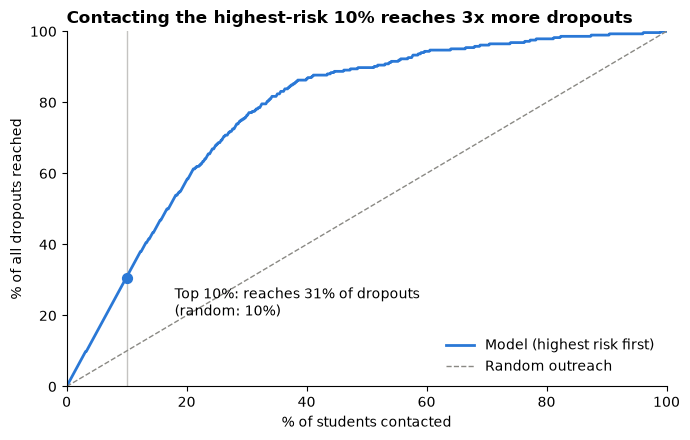

In [3]:
BLUE, GRAY = '#2a78d6', '#8a8984'
pct_contacted = np.arange(1, len(results) + 1) / len(results) * 100
pct_reached = results['dropped_out'].cumsum().values / total * 100

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.plot(pct_contacted, pct_reached, color=BLUE, linewidth=2, label='Model (highest risk first)')
ax.plot([0, 100], [0, 100], color=GRAY, linestyle='--', linewidth=1, label='Random outreach')
ax.axvline(10, color=GRAY, linewidth=1, alpha=0.5)
ax.scatter([10], [pct_reached[BUDGET - 1]], color=BLUE, s=50, zorder=3)
ax.annotate(f'Top 10%: reaches {pct_reached[BUDGET - 1]:.0f}% of dropouts\n(random: 10%)',
            xy=(10, pct_reached[BUDGET - 1]), xytext=(18, 20), fontsize=10)
ax.set_title('Contacting the highest-risk 10% reaches 3x more dropouts', loc='left', fontweight='bold')
ax.set_xlabel('% of students contacted')
ax.set_ylabel('% of all dropouts reached')
ax.set_xlim(0, 100)
ax.set_ylim(0, 100)
ax.spines[['top', 'right']].set_visible(False)
ax.legend(frameon=False, loc='lower right')
fig.tight_layout()
fig.savefig('../charts/9_outreach.png', dpi=150)
plt.show()

**Takeaway:** The blue line shows how many dropouts the office reaches as it works down the ranked list. It rises steeply at first, because the highest-risk students almost all drop out. Then it flattens. Reaching 20% of students would catch 58% of dropouts, and 40% would catch 87%. The gap between the blue line and the dashed line is the value the model adds.

In [4]:
def segment(row):
    money = row['Tuition fees up to date'] == 0 or row['Debtor'] == 1
    enrolled = row['Curricular units 1st sem (enrolled)']
    passed = row['Curricular units 1st sem (approved)']
    grades = enrolled == 0 or passed / enrolled < 0.5
    if money and grades:
        return 'Both'
    if money:
        return 'Money'
    if grades:
        return 'Grades'
    return 'Other'

HELP = {'Both': 'Advisor meeting', 'Money': 'Financial aid office',
        'Grades': 'Tutoring', 'Other': 'Light check-in'}

results['segment'] = results.apply(segment, axis=1)
results['help'] = results['segment'].map(HELP)
flagged = results[results['risk'] >= CUTOFF]
flagged['segment'].value_counts()

segment
Other     138
Grades    111
Both       83
Money      50
Name: count, dtype: int64

**Notes:** I sorted flagged students by *why* they're at risk, using simple rules an advisor can understand:
- **Money:** tuition not up to date or in debt → financial aid office
- **Grades:** passed fewer than half of semester 1 courses → tutoring
- **Both** → advisor meeting (needs the most support)
- **Other:** flagged, but with no clear money or grade problem → light check-in

Rules like these are easy to explain and check, which matters more than a fancy method when decisions affect students.

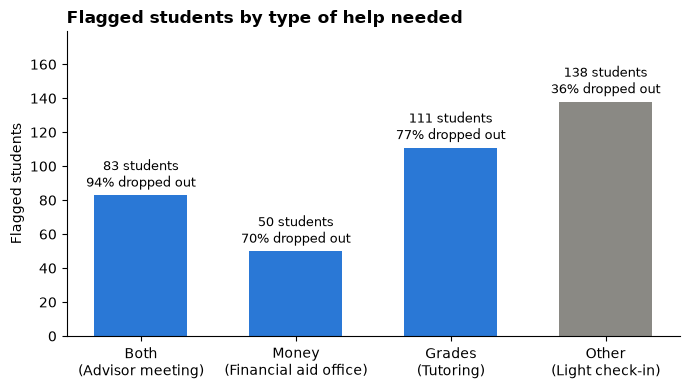

,students,dropout_rate,help
segment,,,
Both,83,94.0,Advisor meeting
Money,50,70.0,Financial aid office
Grades,111,77.0,Tutoring
Other,138,36.0,Light check-in


In [5]:
seg = flagged.groupby('segment').agg(students=('dropped_out', 'size'),
                                     dropout_rate=('dropped_out', 'mean'))
seg = seg.loc[['Both', 'Money', 'Grades', 'Other']]
seg['dropout_rate'] = (seg['dropout_rate'] * 100).round(0)
seg['help'] = seg.index.map(HELP)

fig, ax = plt.subplots(figsize=(7, 4))
labels = [f'{s}\n({HELP[s]})' for s in seg.index]
bars = ax.bar(labels, seg['students'], color=[BLUE, BLUE, BLUE, GRAY], width=0.6)
ax.bar_label(bars, labels=[f"{n} students\n{r:.0f}% dropped out"
                           for n, r in zip(seg['students'], seg['dropout_rate'])],
             padding=3, fontsize=9)
ax.set_title('Flagged students by type of help needed', loc='left', fontweight='bold')
ax.set_ylabel('Flagged students')
ax.set_ylim(0, seg['students'].max() * 1.3)
ax.spines[['top', 'right']].set_visible(False)
fig.tight_layout()
fig.savefig('../charts/10_segments.png', dpi=150)
plt.show()
seg

**Takeaway:** Of the 382 flagged students:
- **Both (83):** 94% really dropped out. They have the highest need, so they get advisor meetings first.
- **Grades (111):** 77% dropped out, so tutoring.
- **Money (50):** 70% dropped out, so the financial aid office.
- **Other (138):** only 36% dropped out. **Most false alarms are here.** These students were flagged for reasons like age, gender, or course, not a clear problem. That links to the fairness results, so they should get only a light, friendly check-in and never a "high risk" label.

In [6]:
outreach = results.head(BUDGET)[['risk', 'segment', 'help', 'dropped_out']].copy()
outreach['risk'] = outreach['risk'].round(3)
outreach.insert(0, 'rank', range(1, BUDGET + 1))
print(outreach['help'].value_counts())
outreach.head(10)

help
Advisor meeting         58
Tutoring                24
Financial aid office     5
Light check-in           1
Name: count, dtype: int64


,rank,risk,segment,help,dropped_out
3533,1,1.000,Both,Advisor meeting,1
2004,2,1.000,Both,Advisor meeting,1
1381,3,1.000,Both,Advisor meeting,1
689,4,0.999,Both,Advisor meeting,1
1572,5,0.999,Both,Advisor meeting,1
678,6,0.999,Both,Advisor meeting,1
716,7,0.999,Grades,Tutoring,1
2021,8,0.999,Both,Advisor meeting,1
1548,9,0.999,Both,Advisor meeting,1
1204,10,0.999,Both,Advisor meeting,1


**Takeaway:** This is the list an advising office would actually use: 88 students ranked by risk, each matched to a type of help. Most (58) need an advisor meeting because they have both money and grade trouble, 24 need tutoring, 5 need financial aid, and 1 gets a light check-in. The `dropped_out` column is only for checking. In real use, the outcome isn't known yet.

In [7]:
COST_MISS, COST_FALSE_ALARM = 5, 1
plans = []
for name, contacted in [('Top 10% (88 students)', results.head(BUDGET)),
                        ('Cutoff 0.35 (all flagged)', results[results['risk'] >= CUTOFF])]:
    caught = contacted['dropped_out'].sum()
    false_alarms = len(contacted) - caught
    missed = total - caught
    plans.append({'plan': name, 'contacted': len(contacted), 'dropouts_reached': caught,
                  'false_alarms': false_alarms, 'missed': missed,
                  'total_cost': missed * COST_MISS + false_alarms * COST_FALSE_ALARM})
pd.DataFrame(plans)

,plan,contacted,dropouts_reached,false_alarms,missed,total_cost
0,Top 10% (88 students),88,87,1,197,986
1,Cutoff 0.35 (all flagged),382,249,133,35,308


**Takeaway: the cost of mistakes, in plain words**
- **Missed student** (model says fine, student drops out): the student loses their degree. This is the most costly mistake, so I weighted it 5x.
- **False alarm** (model flags a student who would have been fine): a wasted advisor hour, and the student may feel labeled.

**Top 10%** is very precise (only 1 false alarm) but misses 197 dropouts. **Cutoff 0.35** reaches 249 dropouts and misses only 35, but needs 382 contacts, 133 of them false alarms. By total cost, the wider plan is much better (308 vs. 986), if the college can afford it.

**Recommendation: a tiered plan.** Give the top 10% full support (advisor meeting, tutoring, or financial aid by segment). Give the rest of the flagged students lighter, low-cost outreach, like an email or a group workshop. This reaches most dropouts without overloading advisors.

## Outreach summary
- **Top 10% works:** 87 of the 88 highest-risk students really dropped out. That's 31% of all dropouts reached, vs. 10% at random.
- **Different students need different help:** of 382 flagged students, 83 need an advisor (both problems, 94% dropped out), 111 tutoring (77%), and 50 financial aid (70%).
- **"Other" is where false alarms live:** 138 students flagged with no clear problem, and only 36% dropped out. They get a light check-in, never a label.
- **Plan:** tiered outreach. Full support for the top 10%, light outreach for the rest of the flagged students. An advisor always makes the final call.